In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [121]:
nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gunja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gunja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [122]:
df = pd.read_csv("neww.csv")

In [123]:
df.head()


,text,label
0,I feel happy today,Normal
1,I woke up feeling refreshed,Normal
2,Today has been a good day,Normal
3,I enjoyed my breakfast this morning,Normal
4,I had a peaceful night's sleep,Normal


In [124]:
df.rename(columns={
    "statement":"text",
    "status":"label"
},inplace=True)

In [125]:
df.isnull().sum()
df.dropna(inplace=True)

In [126]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [127]:
df.shape

(957, 2)

In [128]:
df["label"].value_counts()

label
Stress                  239
Normal                  160
Depression              160
Personality Disorder    159
Anxiety                 158
Bipolar                  81
Name: count, dtype: int64

In [148]:
tfidf = model.named_steps["tfidf"]

for word in ["worn", "out", "worn out"]:
    print(word, "->", tfidf.vocabulary_.get(word))

worn -> 1018
out -> 656
worn out -> 1019


In [149]:
print(model.predict(["I am worn out"]))

['Stress']


In [150]:
print(model.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality Disorder' 'Stress']


In [129]:
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [130]:
df["text"] = df["text"].apply(preprocess)

In [131]:
X = df["text"]

y = df["label"]

In [132]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [133]:
model = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)
    ),

    (
        "rf",
    RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
        )
   ] )



In [134]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Anxiety','Bipolar','Depression','Normal','Personality Disorder','Stress']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",15000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'


In [135]:
print("✅ Training completed")

rf = model.named_steps["rf"]
print("Trees:", len(rf.estimators_))

✅ Training completed
Trees: 500


In [136]:
y_pred = model.predict(X_test)

In [137]:
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.703125


In [138]:
print(classification_report(y_test,y_pred))

                      precision    recall  f1-score   support

             Anxiety       0.71      0.69      0.70        32
             Bipolar       0.83      0.62      0.71        16
          Depression       0.56      0.69      0.62        32
              Normal       0.68      0.72      0.70        32
Personality Disorder       0.76      0.78      0.77        32
              Stress       0.77      0.69      0.73        48

            accuracy                           0.70       192
           macro avg       0.72      0.70      0.70       192
        weighted avg       0.71      0.70      0.70       192



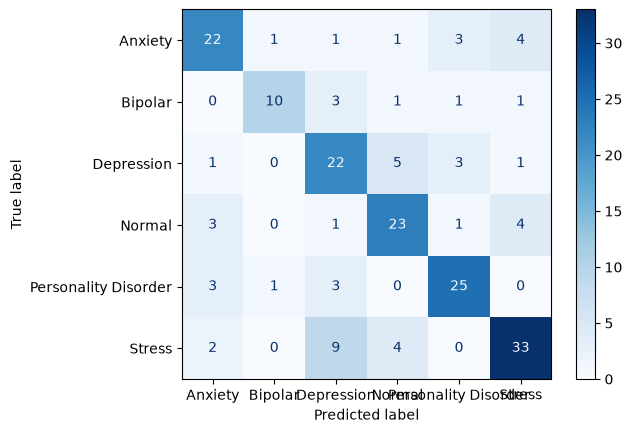

<Figure size 2400x1000 with 0 Axes>

In [139]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")
plt.figure(figsize=(24,10))

plt.show()

In [140]:
joblib.dump(model, "mental_health_model.pkl")


['mental_health_model.pkl']

In [141]:
samples = [
    "I feel lonely",
    "I feel like crying",
    "I am scared all the time",
    "I don't enjoy anything anymore",
    "I feel anxious around people",
    "I am happy today"
]

for s in samples:
    print(s)
    print(model.predict([s])[0])
    print(model.predict_proba([s]).max())
    print("-"*40)

I feel lonely
Depression
0.25690250437167683
----------------------------------------
I feel like crying
Depression
0.5335710998714024
----------------------------------------
I am scared all the time
Normal
0.3151344572056869
----------------------------------------
I don't enjoy anything anymore
Depression
0.6044566059817764
----------------------------------------
I feel anxious around people
Personality Disorder
0.32654393331070475
----------------------------------------
I am happy today
Normal
0.4103391235609529
----------------------------------------


In [142]:
print(type(model))
print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=30,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])


In [143]:
rf = model.named_steps["rf"]

print("Number of trees:", len(rf.estimators_))

Number of trees: 500


In [144]:
keywords = ["lonely", "cry", "crying", "scared", "anxious", "happy"]

for word in keywords:
    print(f"\n========== {word.upper()} ==========")

    matches = df[df["text"].str.contains(word, case=False, na=False)]

    print(matches[["text", "label"]].head(10))

    print("\nLabel counts:")
    print(matches["label"].value_counts())

    print("-"*80)


========== LONELY ==========
                                         text       label
99   i feel lonely even with people around me  Depression
432         feeling lonely even around people  Depression

Label counts:
label
Depression    2
Name: count, dtype: int64
--------------------------------------------------------------------------------

========== CRY ==========
                                           text       label
92              i have been cry more than usual  Depression
127             i cry myself to sleep sometimes  Depression
177  i went from laughing to cry within an hour     Bipolar
404                     cry without knowing why  Depression

Label counts:
label
Depression    3
Bipolar       1
Name: count, dtype: int64
--------------------------------------------------------------------------------

========== CRYING ==========
Empty DataFrame
Columns: [text, label]
Index: []

Label counts:
Series([], Name: count, dtype: int64)
---------------------------------

In [145]:
tests = [
    "I am depressed",
    "I have depression",
    "I feel depressed",
    "I am feeling depressed",
    "I don't want to get out of bed",
    "I have no friends",
    "I am lonely"
]

for t in tests:
    print(t)
    print(model.predict([t])[0])
    print(model.predict_proba([t]))
    print()

I am depressed
Stress
[[0.13901016 0.10316317 0.12004977 0.12461778 0.15232824 0.36083088]]

I have depression
Depression
[[0.14516153 0.19185185 0.22640933 0.1000408  0.13118193 0.20535456]]

I feel depressed
Depression
[[0.1602238  0.15427379 0.25368196 0.15239392 0.13765482 0.14177172]]

I am feeling depressed
Stress
[[0.13021108 0.08987209 0.14747829 0.1164568  0.19065664 0.32532511]]

I don't want to get out of bed
Depression
[[0.15541963 0.1671073  0.30789168 0.09561272 0.15423991 0.11972876]]

I have no friends
Depression
[[0.12553482 0.17367389 0.28401734 0.08198087 0.11073807 0.22405501]]

I am lonely
Stress
[[0.13826122 0.10266019 0.12331688 0.12405897 0.15157737 0.36012537]]



In [146]:
tfidf = model.named_steps["tfidf"]

print(tfidf.vocabulary_.get("depressed"))

None


In [147]:
words = ["depressed", "depression", "lonely", "friends", "bed"]

tfidf = model.named_steps["tfidf"]

for word in words:
    print(word, "->", tfidf.vocabulary_.get(word))
    

depressed -> None
depression -> None
lonely -> 510
friends -> None
bed -> 79
